In [1]:
# @title ⚙️ Cell 1: Setup & Imports
!pip install -q torch matplotlib numpy

import math, random, os, json
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from collections import defaultdict

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Setup complete.")

Using device: cuda
Setup complete.


In [2]:
# @title 📄 Cell 2: GPT Model (model.py)
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias   = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn        = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj        = nn.Linear(config.n_embd, config.n_embd,     bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head  = config.n_head
        self.n_embd  = config.n_embd
        self.dropout = config.dropout
        self.flash   = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias",
                torch.tril(torch.ones(config.block_size, config.block_size))
                    .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                    dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y   = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int  = 1024
    vocab_size: int  = 50304
    n_layer:    int  = 12
    n_head:     int  = 12
    n_embd:     int  = 768
    dropout:    float = 0.0
    bias:       bool  = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))
        print(f"GPT | params: {self.get_num_params()/1e6:.2f}M")

    def get_num_params(self, non_embedding=True):
        n = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n -= self.transformer.wpe.weight.numel()
        return n

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        device = idx.device
        b, t   = idx.size()
        assert t <= self.config.block_size, f"Sequence length {t} > block_size {self.config.block_size}"
        pos     = torch.arange(0, t, dtype=torch.long, device=device)
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        return self.lm_head(x)

print("model.py loaded.")

model.py loaded.


In [3]:
# @title 📦 Cell 3: Datasets & Data Generation

# ── Character-level dataset (sanity check) ────────────────────────────────────
class CharDataset(Dataset):
    def __init__(self, text, block_size):
        chars = sorted(set(text))
        self.stoi       = {c: i for i, c in enumerate(chars)}
        self.itos       = {i: c for c, i in self.stoi.items()}
        self.vocab_size = len(chars)
        self.block_size = block_size
        self.data = torch.tensor([self.stoi[c] for c in text], dtype=torch.long)
    def __len__(self):  return max(1, len(self.data) - self.block_size)
    def __getitem__(self, idx):
        return self.data[idx:idx+self.block_size], self.data[idx+1:idx+self.block_size+1]
    def decode(self, tokens): return "".join(self.itos[t] for t in tokens)

# ── Modular arithmetic dataset ────────────────────────────────────────────────
class ModArithDataset(Dataset):
    def __init__(self, sequences):
        self.data = torch.tensor(sequences, dtype=torch.long)
    def __len__(self):  return len(self.data)
    def __getitem__(self, idx):
        seq = self.data[idx]
        return seq[:-1], seq[1:]   # x=[a,op,b,=]  y=[op,b,=,c]

def get_op_tokens(p):
    """Token IDs: 0..p-1 are numbers; p='+', p+1='-', p+2='/', p+3='='"""
    return {'+': p, '-': p+1, '/': p+2, '=': p+3}, p + 4

def mod_div(a, b, p):
    """a / b mod p (Fermat's little theorem; p must be prime, b != 0)"""
    return (a * pow(b, p - 2, p)) % p

def generate_mod_data(p, op, train_frac=0.5, val_frac=0.1, seed=42):
    """
    Build all (a op b = c) sequences, shuffle, split into train/val/test.
    Sequence tokens: [a, op_tok, b, eq_tok, c]  (length 5)
    Loss computed only on the last token (c = answer).
    """
    rng = random.Random(seed)
    op_tokens, _ = get_op_tokens(p)
    op_tok = op_tokens[op]
    eq_tok = op_tokens['=']

    seqs = []
    for a in range(p):
        for b in range(p):
            if op == '/' and b == 0: continue
            c = mod_div(a, b, p) if op == '/' else \
                ((a + b) % p)    if op == '+' else \
                ((a - b) % p)
            seqs.append([a, op_tok, b, eq_tok, c])

    rng.shuffle(seqs)
    n    = len(seqs)
    n_tr = int(n * train_frac)
    n_va = int(n * val_frac)
    return seqs[:n_tr], seqs[n_tr:n_tr+n_va], seqs[n_tr+n_va:]

# ── Print dataset summary (Part 2.1 deliverable) ──────────────────────────────
print(f"{'Task':<5} {'p':<5} {'Total':>7} {'Train':>7} {'Val':>6} {'Test':>7}")
print("-" * 45)
data_store = {}
for p in [97, 113]:
    for op in ['+', '-', '/']:
        tr, va, te = generate_mod_data(p, op, seed=42)
        data_store[(p, op)] = (tr, va, te)
        total = len(tr) + len(va) + len(te)
        print(f"  {op!r:<4} {p:<5} {total:>7} {len(tr):>7} {len(va):>6} {len(te):>7}")

Task  p       Total   Train    Val    Test
---------------------------------------------
  '+'  97       9409    4704    940    3765
  '-'  97       9409    4704    940    3765
  '/'  97       9312    4656    931    3725
  '+'  113     12769    6384   1276    5109
  '-'  113     12769    6384   1276    5109
  '/'  113     12656    6328   1265    5063


In [4]:
# @title 🔁 Cell 4: train.py & inference.py

def train_model(model, train_loader, test_loader, cfg, device=DEVICE):
    """
    General training loop.  cfg keys:
      lr, weight_decay, betas, max_steps, eval_interval
      loss_type : 'last'  → cross-entropy only on answer token (Part 2)
                  'full'  → all token positions (sanity check)
      mask_start: int     → skip loss on first N positions (sanity check 2)
    Returns dict with keys: step, train_loss, train_acc, test_loss, test_acc
    """
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.get('lr', 1e-3),
        weight_decay=cfg.get('weight_decay', 1.0),
        betas=cfg.get('betas', (0.9, 0.98)),
    )
    loss_type  = cfg.get('loss_type', 'last')
    mask_start = cfg.get('mask_start', 0)
    max_steps  = cfg.get('max_steps', 10_000)
    eval_every = cfg.get('eval_interval', 500)
    log = defaultdict(list)

    def loss_and_acc(logits, y):
        if loss_type == 'last':
            loss = F.cross_entropy(logits[:, -1, :], y[:, -1])
            acc  = (logits[:, -1, :].argmax(-1) == y[:, -1]).float().mean().item()
        else:
            if mask_start > 0:
                logits = logits[:, mask_start:, :]
                y      = y[:, mask_start:]
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.reshape(B*T, V), y.reshape(B*T))
            acc  = (logits.argmax(-1) == y).float().mean().item()
        return loss, acc

    model.train()
    step    = 0
    tr_iter = iter(train_loader)

    while step < max_steps:
        try:    x, y = next(tr_iter)
        except StopIteration:
            tr_iter = iter(train_loader)
            x, y = next(tr_iter)

        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss, acc = loss_and_acc(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1

        if step % eval_every == 0:
            log['step'].append(step)
            log['train_loss'].append(loss.item())
            log['train_acc'].append(acc)
            model.eval()
            with torch.no_grad():
                vl, va = [], []
                for vx, vy in test_loader:
                    vx, vy = vx.to(device), vy.to(device)
                    l2, a2 = loss_and_acc(model(vx), vy)
                    vl.append(l2.item()); va.append(a2)
            log['test_loss'].append(np.mean(vl))
            log['test_acc'].append(np.mean(va))
            model.train()
            if step % (eval_every * 10) == 0:
                print(f"  step {step:6d} | tr_loss={loss.item():.4f} tr_acc={acc:.3f}"
                      f" | te_loss={np.mean(vl):.4f} te_acc={np.mean(va):.3f}")

    return {k: list(v) for k, v in log.items()}


# ── inference.py ──────────────────────────────────────────────────────────────
@torch.no_grad()
def load_char_model(ckpt_path, device=DEVICE):
    ckpt  = torch.load(ckpt_path, map_location=device)
    model = GPT(ckpt['config']).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt['stoi'], ckpt['itos']

@torch.no_grad()
def char_generate(model, prompt_str, stoi, itos, max_new=30, device=DEVICE):
    tokens = [stoi[c] for c in prompt_str]
    x = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    for _ in range(max_new):
        x_cond = x[:, -model.config.block_size:]
        nxt    = model(x_cond)[:, -1, :].argmax(-1, keepdim=True)
        x      = torch.cat([x, nxt], dim=1)
    return "".join(itos[t.item()] for t in x[0])

@torch.no_grad()
def predict_mod_arith(model, a, b, op, p, device=DEVICE):
    op_tokens, _ = get_op_tokens(p)
    x = torch.tensor([[a, op_tokens[op], b, op_tokens['=']]], dtype=torch.long).to(device)
    model.eval()
    return model(x)[0, -1, :].argmax(-1).item()

print("Training & inference functions ready.")

Training & inference functions ready.


Vocab (14): [' ', 'I', 'a', 'c', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'r', 'v']
GPT | params: 0.05M
  step    0 | loss = 2.696866
  step  500 | loss = 0.003624
  step 1000 | loss = 0.001015
  step 1500 | loss = 0.000461
  step 2000 | loss = 0.000255
  step 2500 | loss = 0.000156


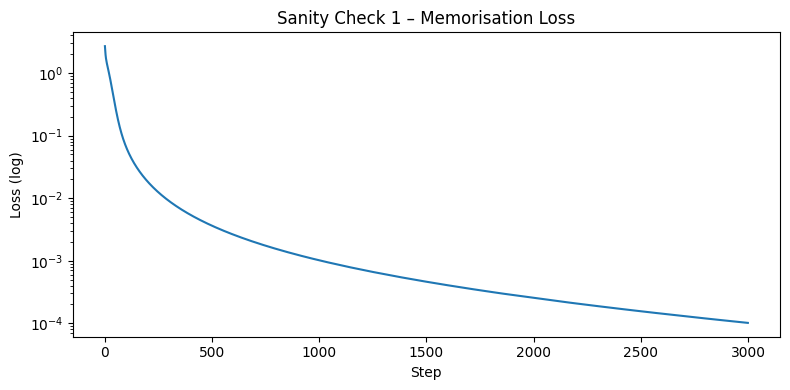


Generated : 'I love machine learnin'
Expected  : 'I love machine learning'
Exact match: False
Checkpoint saved: sc1_ckpt.pt


In [5]:
# @title ✅ Cell 5: Part 1.5 – Sanity Check 1: Memorise "I love machine learning"
set_seed(42)
TEXT = "I love machine learning"
ds_sc = CharDataset(TEXT, block_size=len(TEXT) - 1)
print(f"Vocab ({ds_sc.vocab_size}): {sorted(ds_sc.stoi.keys())}")

x_sc = ds_sc.data[:-1].unsqueeze(0).to(DEVICE)   # (1, T-1)
y_sc = ds_sc.data[1:].unsqueeze(0).to(DEVICE)    # (1, T-1)

cfg_sc = GPTConfig(block_size=len(TEXT)-1, vocab_size=ds_sc.vocab_size,
                   n_layer=1, n_head=2, n_embd=64, dropout=0.0, bias=True)
model_sc1 = GPT(cfg_sc).to(DEVICE)
opt_sc1   = torch.optim.Adam(model_sc1.parameters(), lr=1e-3)

losses_sc1 = []
for step in range(3000):
    opt_sc1.zero_grad()
    logits = model_sc1(x_sc)
    B, T, V = logits.shape
    loss = F.cross_entropy(logits.view(B*T, V), y_sc.view(B*T))
    loss.backward(); opt_sc1.step()
    losses_sc1.append(loss.item())
    if step % 500 == 0:
        print(f"  step {step:4d} | loss = {loss.item():.6f}")

plt.figure(figsize=(8, 4))
plt.plot(losses_sc1)
plt.yscale('log'); plt.title("Sanity Check 1 – Memorisation Loss")
plt.xlabel("Step"); plt.ylabel("Loss (log)"); plt.tight_layout(); plt.show()

# ── Inference ──
model_sc1.eval()
with torch.no_grad():
    x_gen = ds_sc.data[:1].unsqueeze(0).to(DEVICE)
    for _ in range(len(TEXT) - 1):
        nxt = model_sc1(x_gen)[:, -1, :].argmax(-1, keepdim=True)
        x_gen = torch.cat([x_gen, nxt], dim=1)
gen_sc1 = ds_sc.decode(x_gen[0].cpu().tolist())

print(f"\nGenerated : '{gen_sc1}'")
print(f"Expected  : '{TEXT}'")
print(f"Exact match: {gen_sc1 == TEXT}")

torch.save({'model_state_dict': model_sc1.state_dict(), 'config': cfg_sc,
            'stoi': ds_sc.stoi, 'itos': ds_sc.itos}, 'sc1_ckpt.pt')
print("Checkpoint saved: sc1_ckpt.pt")

GPT | params: 0.05M
  step    0 | masked loss = 2.688064
  step  500 | masked loss = 0.003658
  step 1000 | masked loss = 0.001030
  step 1500 | masked loss = 0.000469
  step 2000 | masked loss = 0.000259
  step 2500 | masked loss = 0.000159


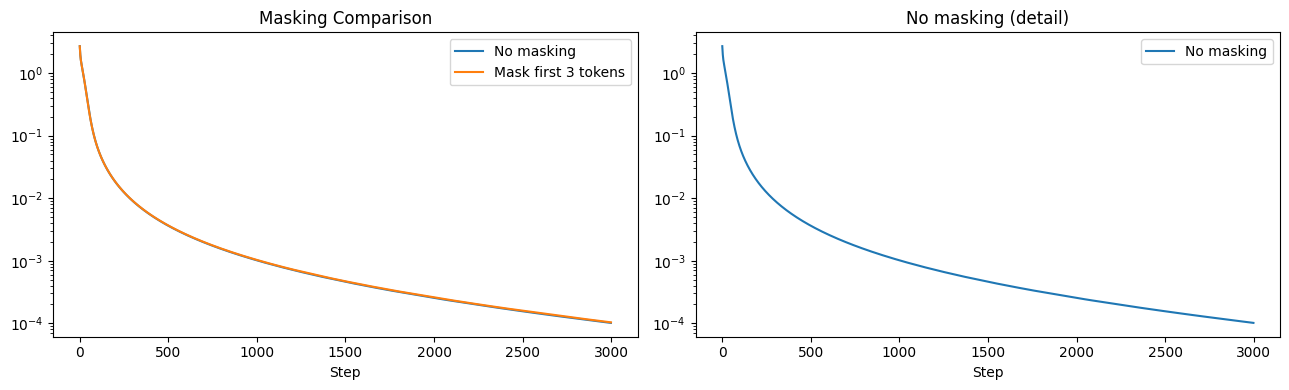

Sanity check 2 complete.


In [6]:
# @title ✅ Cell 6: Part 1.5 – Sanity Check 2: Mask loss on first 3 tokens
MASK_K = 3
set_seed(42)
model_sc2 = GPT(cfg_sc).to(DEVICE)
opt_sc2   = torch.optim.Adam(model_sc2.parameters(), lr=1e-3)

losses_sc2 = []
for step in range(3000):
    opt_sc2.zero_grad()
    logits = model_sc2(x_sc)                 # (1, T-1, V)
    logits_m = logits[:, MASK_K:, :]         # mask first 3 positions
    y_m      = y_sc[:, MASK_K:]
    B, T2, V = logits_m.shape
    loss = F.cross_entropy(logits_m.view(B*T2, V), y_m.view(B*T2))
    loss.backward(); opt_sc2.step()
    losses_sc2.append(loss.item())
    if step % 500 == 0:
        print(f"  step {step:4d} | masked loss = {loss.item():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses_sc1, label='No masking')
axes[0].plot(losses_sc2, label='Mask first 3 tokens')
axes[0].set_yscale('log'); axes[0].set_title("Masking Comparison")
axes[0].set_xlabel("Step"); axes[0].legend()
axes[1].plot(losses_sc1, label='No masking', color='C0')
axes[1].set_yscale('log'); axes[1].set_title("No masking (detail)")
axes[1].set_xlabel("Step"); axes[1].legend()
plt.tight_layout(); plt.show()

torch.save({'model_state_dict': model_sc2.state_dict(), 'config': cfg_sc,
            'stoi': ds_sc.stoi, 'itos': ds_sc.itos, 'mask_k': MASK_K}, 'sc2_ckpt.pt')
print("Sanity check 2 complete.")

In [7]:
# @title Cell 7 – Part 2.2: Addition & Subtraction (complete, optimised)

# ── Verify GPU is active ──────────────────────────────────────────────────────
print(f"Device : {DEVICE}")
if DEVICE == 'cpu':
    print("WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU")
    print("         Rerun from Cell 1 after switching. CPU will take hours.")

# ── Config ────────────────────────────────────────────────────────────────────
# 30k steps is sufficient for add/sub to fully converge.
# The assignment says "up to 10^5" — that is a ceiling, not a requirement.
TRAIN_CFG_22 = dict(
    lr            = 1e-3,
    weight_decay  = 1.0,
    betas         = (0.9, 0.98),
    max_steps     = 30_000,
    eval_interval = 1_000,
    loss_type     = 'last',
)

SEEDS   = [42, 123, 777]
PRIMES  = [97, 113]
OPS     = ['+', '-']
LAYERS  = [1, 2]

results_22 = []
total_runs  = len(SEEDS) * len(PRIMES) * len(OPS) * len(LAYERS)
run_idx     = 0

for p in PRIMES:
    _, vocab_size = get_op_tokens(p)

    for op in OPS:
        for n_layer in LAYERS:
            for seed in SEEDS:
                run_idx += 1
                tag = f"p{p}_{op}_L{n_layer}_s{seed}"
                print(f"\n[{run_idx:02d}/{total_runs}] {tag}")

                # ── Data ──────────────────────────────────────────────────────
                set_seed(seed)
                tr, _, te = generate_mod_data(p, op,
                                              train_frac=0.5,
                                              val_frac=0.0,
                                              seed=seed)
                tr_dl = DataLoader(
                    ModArithDataset(tr),
                    batch_size=512,
                    shuffle=True,
                    num_workers=2,
                    pin_memory=(DEVICE == 'cuda'),
                )
                te_dl = DataLoader(
                    ModArithDataset(te),
                    batch_size=1024,        # large eval batch → fewer iterations
                    num_workers=2,
                    pin_memory=(DEVICE == 'cuda'),
                )

                # ── Model ─────────────────────────────────────────────────────
                gpt_cfg = GPTConfig(
                    block_size = 4,
                    vocab_size = vocab_size,
                    n_layer    = n_layer,
                    n_head     = 4,
                    n_embd     = 128,
                    dropout    = 0.0,
                    bias       = False,
                )
                m = GPT(gpt_cfg).to(DEVICE)

                # ── Train ─────────────────────────────────────────────────────
                metrics = train_model(m, tr_dl, te_dl, TRAIN_CFG_22)

                # ── Store ─────────────────────────────────────────────────────
                results_22.append(dict(
                    p               = p,
                    op              = op,
                    n_layer         = n_layer,
                    seed            = seed,
                    tag             = tag,
                    final_train_acc = metrics['train_acc'][-1],
                    final_test_acc  = metrics['test_acc'][-1],
                    final_train_loss= metrics['train_loss'][-1],
                    final_test_loss = metrics['test_loss'][-1],
                    metrics         = metrics,
                ))

                print(f"       train_acc = {metrics['train_acc'][-1]:.4f}"
                      f"  |  test_acc  = {metrics['test_acc'][-1]:.4f}"
                      f"  |  train_loss = {metrics['train_loss'][-1]:.5f}")

print("\n✅ All Part 2.2 runs complete.")

Device : cuda

[01/24] p97_+_L1_s42
GPT | params: 0.21M
  step  10000 | tr_loss=0.1196 tr_acc=0.958 | te_loss=0.1226 te_acc=0.969
  step  20000 | tr_loss=0.0096 tr_acc=1.000 | te_loss=0.0116 te_acc=1.000
  step  30000 | tr_loss=0.0126 tr_acc=1.000 | te_loss=0.0122 te_acc=1.000
       train_acc = 1.0000  |  test_acc  = 1.0000  |  train_loss = 0.01257

[02/24] p97_+_L1_s123
GPT | params: 0.21M
  step  10000 | tr_loss=0.0042 tr_acc=1.000 | te_loss=0.0048 te_acc=1.000
  step  20000 | tr_loss=0.0045 tr_acc=1.000 | te_loss=0.0070 te_acc=1.000
  step  30000 | tr_loss=0.0144 tr_acc=1.000 | te_loss=0.0339 te_acc=0.995
       train_acc = 1.0000  |  test_acc  = 0.9950  |  train_loss = 0.01440

[03/24] p97_+_L1_s777
GPT | params: 0.21M
  step  10000 | tr_loss=0.0183 tr_acc=1.000 | te_loss=0.0227 te_acc=1.000
  step  20000 | tr_loss=0.0131 tr_acc=1.000 | te_loss=0.0178 te_acc=1.000
  step  30000 | tr_loss=0.0164 tr_acc=1.000 | te_loss=0.0182 te_acc=1.000
       train_acc = 1.0000  |  test_acc  = 1.

Run                        L  Seed   TrainAcc   TestAcc   TrainLoss   TestLoss
──────────────────────────────────────────────────────────────────────────────
  p=97 op='+'              1    42     1.0000    1.0000     0.01257    0.01216
  p=97 op='+'              1   123     1.0000    0.9950     0.01440    0.03394
  p=97 op='+'              1   777     1.0000    1.0000     0.01641    0.01825
  p=97 op='+'              2    42     1.0000    1.0000     0.00293    0.00308
  p=97 op='+'              2   123     1.0000    1.0000     0.00182    0.00188
  p=97 op='+'              2   777     1.0000    0.9877     0.03956    0.06039
  p=97 op='-'              1    42     1.0000    1.0000     0.00088    0.00093
  p=97 op='-'              1   123     1.0000    1.0000     0.00109    0.00114
  p=97 op='-'              1   777     1.0000    1.0000     0.00029    0.00030
  p=97 op='-'              2    42     1.0000    0.9930     0.02069    0.05048
  p=97 op='-'              2   123     1.0000    1.0

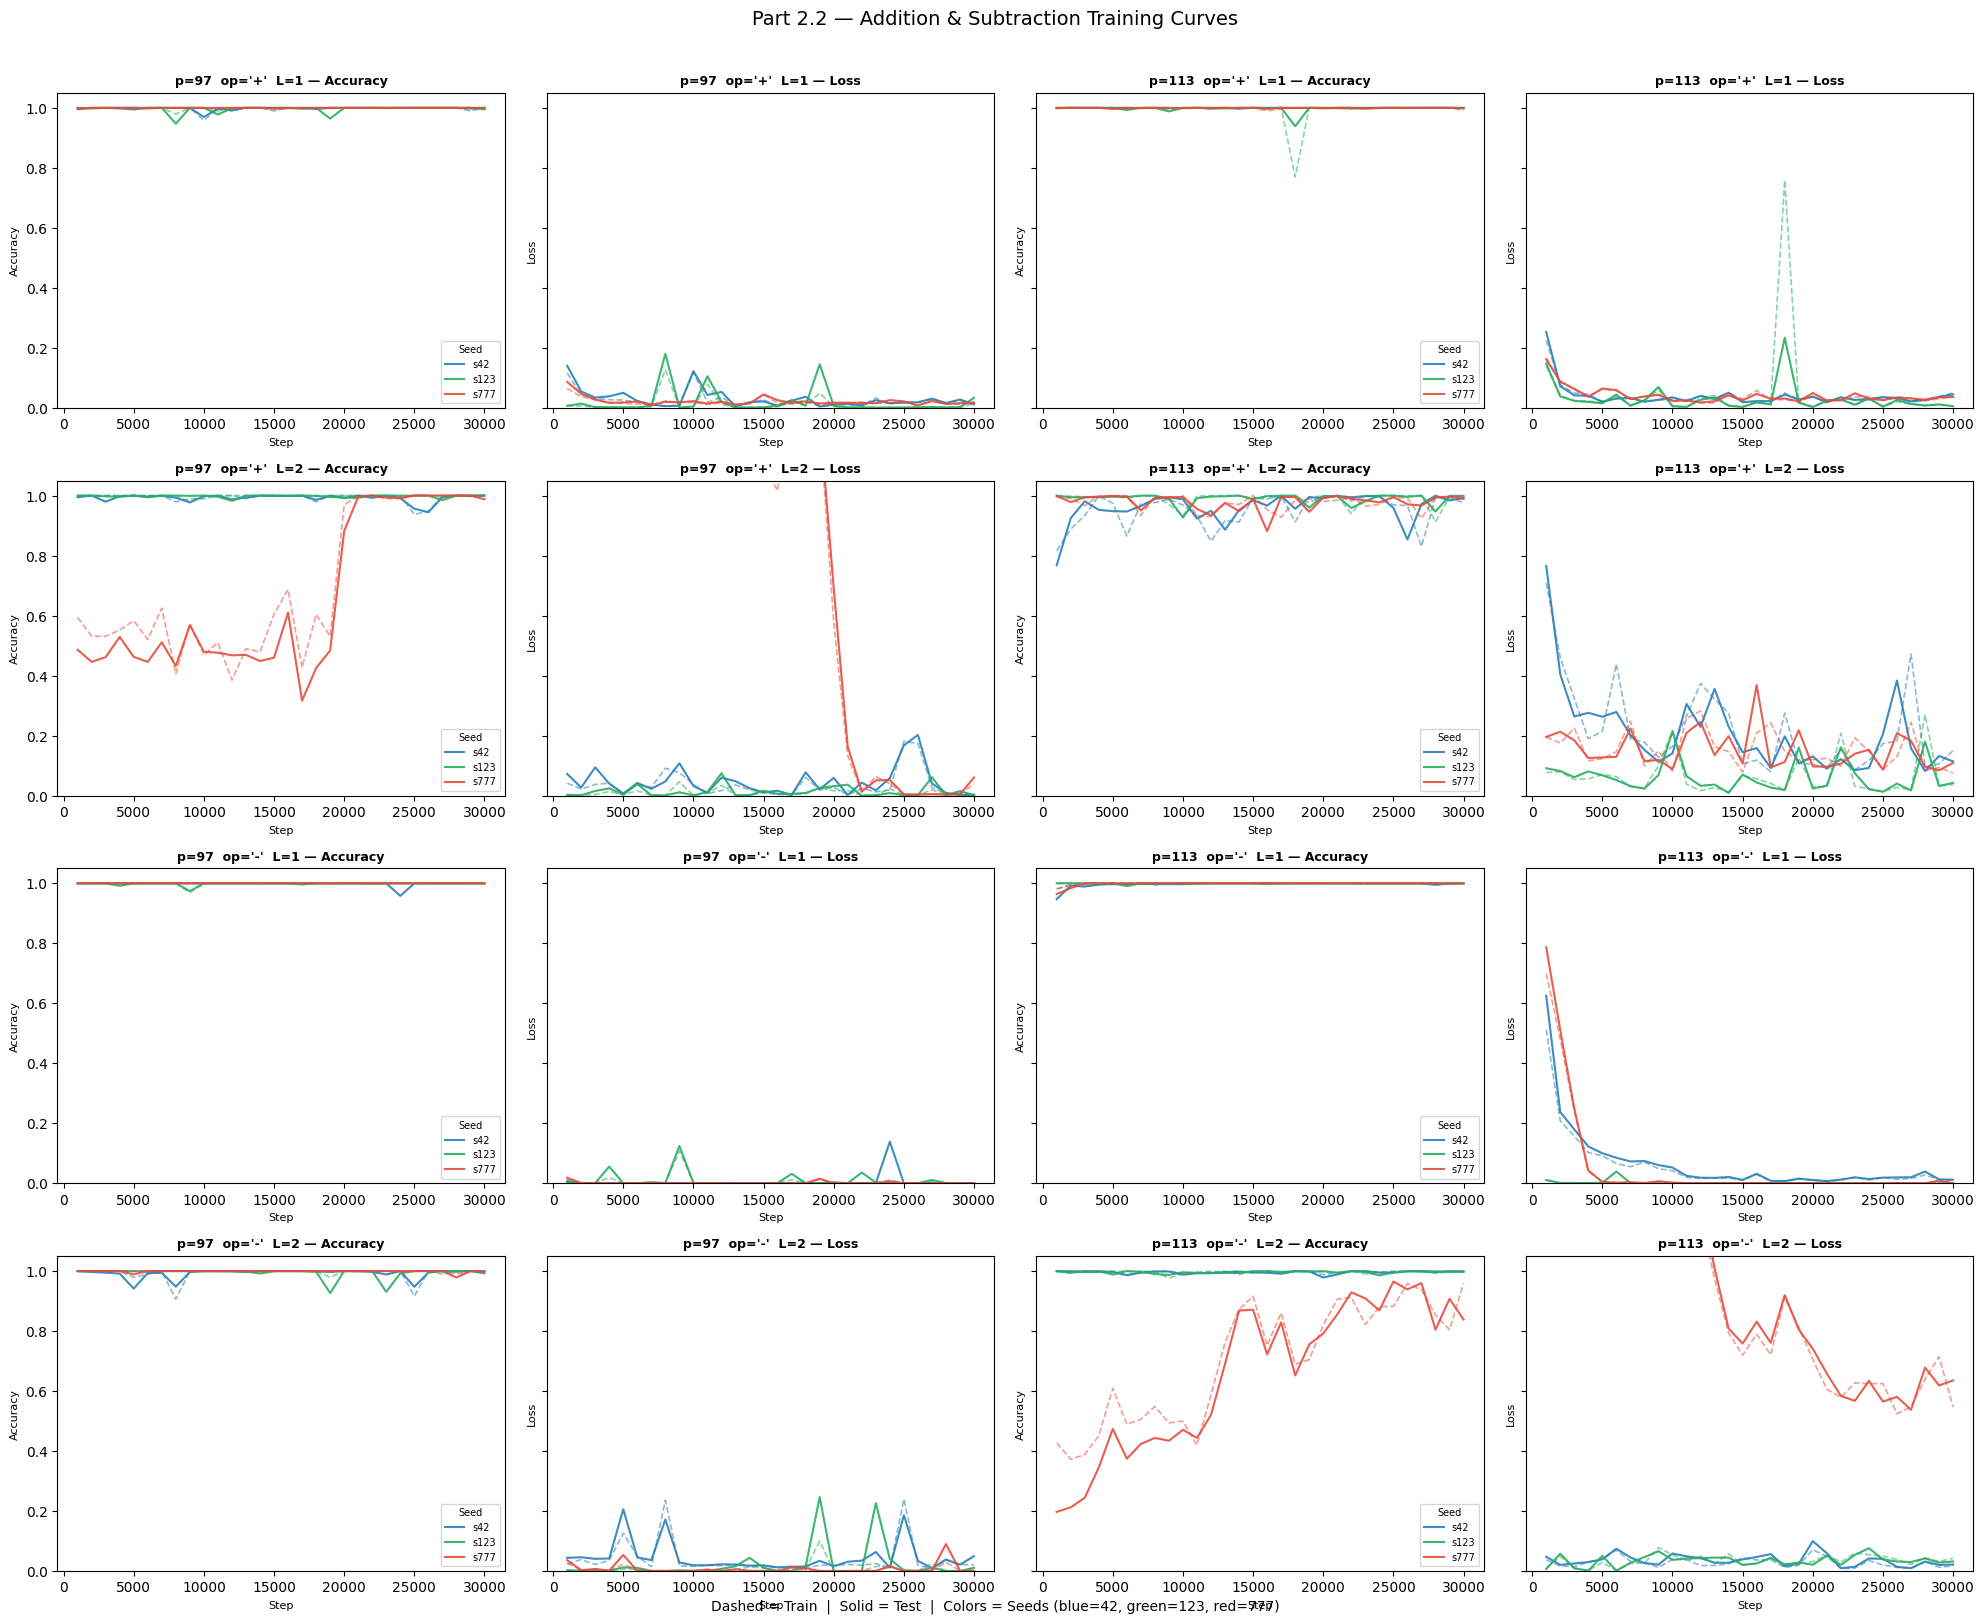

Plot saved: part22_curves.png


In [8]:
# @title Cell 8 – Part 2.2: Results Table + Training Curves

import warnings
warnings.filterwarnings('ignore')

# ── Summary table ─────────────────────────────────────────────────────────────
header = f"{'Run':<25} {'L':>2}  {'Seed':>4}  {'TrainAcc':>9}  {'TestAcc':>8}  {'TrainLoss':>10}  {'TestLoss':>9}"
print(header)
print("─" * len(header))

for r in results_22:
    label = f"p={r['p']} op={r['op']!r}"
    print(f"  {label:<23} {r['n_layer']:>2}  {r['seed']:>4}"
          f"  {r['final_train_acc']:>9.4f}  {r['final_test_acc']:>8.4f}"
          f"  {r['final_train_loss']:>10.5f}  {r['final_test_loss']:>9.5f}")

# ── Aggregate: mean ± std across 3 seeds ─────────────────────────────────────
print("\n── Mean ± Std across 3 seeds ──")
agg_header = f"{'Config':<30}  {'Train Acc':>12}  {'Test Acc':>12}"
print(agg_header)
print("─" * len(agg_header))

for p in [97, 113]:
    for op in ['+', '-']:
        for n_layer in [1, 2]:
            group = [r for r in results_22
                     if r['p'] == p and r['op'] == op and r['n_layer'] == n_layer]
            tr_accs = [r['final_train_acc'] for r in group]
            te_accs = [r['final_test_acc']  for r in group]
            label = f"p={p} op={op!r} L={n_layer}"
            print(f"  {label:<28}  "
                  f"{np.mean(tr_accs):>6.4f} ± {np.std(tr_accs):.4f}  "
                  f"{np.mean(te_accs):>6.4f} ± {np.std(te_accs):.4f}")

# ── Training curves: one subplot per (p, op, n_layer) ────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharey='row')

# Row 0/1 → accuracy, Row 2/3 → loss
row_map   = {('+', 1): 0, ('+', 2): 1, ('-', 1): 2, ('-', 2): 3}
col_map   = {97: 0, 113: 2}          # p=97 → cols 0-1, p=113 → cols 2-3
# within each p-block: col 0 = acc, col 1 = loss

COLORS = {42: '#2980b9', 123: '#27ae60', 777: '#e74c3c'}

for r in results_22:
    row = row_map[(r['op'], r['n_layer'])]
    base_col = col_map[r['p']]
    steps = r['metrics']['step']
    c = COLORS[r['seed']]

    # Accuracy subplot
    ax_acc = axes[row][base_col]
    ax_acc.plot(steps, r['metrics']['train_acc'], '--',
                color=c, alpha=0.55, linewidth=1.2)
    ax_acc.plot(steps, r['metrics']['test_acc'],
                color=c, alpha=0.9,  linewidth=1.5,
                label=f"s{r['seed']}")

    # Loss subplot
    ax_los = axes[row][base_col + 1]
    ax_los.plot(steps, r['metrics']['train_loss'], '--',
                color=c, alpha=0.55, linewidth=1.2)
    ax_los.plot(steps, r['metrics']['test_loss'],
                color=c, alpha=0.9,  linewidth=1.5)

# Formatting
for r_idx, (op, nl) in enumerate([('+',1),('+',2),('-',1),('-',2)]):
    for c_idx, p in enumerate([97, 113]):
        base = c_idx * 2
        axes[r_idx][base].set_title(
            f"p={p}  op={op!r}  L={nl} — Accuracy", fontsize=9, fontweight='bold')
        axes[r_idx][base+1].set_title(
            f"p={p}  op={op!r}  L={nl} — Loss",     fontsize=9, fontweight='bold')
        for ax in [axes[r_idx][base], axes[r_idx][base+1]]:
            ax.set_xlabel("Step", fontsize=8)
        axes[r_idx][base].set_ylim(0, 1.05)
        axes[r_idx][base].set_ylabel("Accuracy", fontsize=8)
        axes[r_idx][base+1].set_ylabel("Loss",   fontsize=8)
        axes[r_idx][base].legend(fontsize=7, title="Seed",
                                 title_fontsize=7, loc='lower right')

# Shared legend note (dashed = train, solid = test)
fig.text(0.5, 0.01,
         "Dashed = Train  |  Solid = Test  |  Colors = Seeds (blue=42, green=123, red=777)",
         ha='center', fontsize=10)

plt.suptitle("Part 2.2 — Addition & Subtraction Training Curves", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("part22_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: part22_curves.png")

Division data: train=4656, test=4656
GPT | params: 0.21M
Training for grokking (this takes ~10-15 min on T4)...
  step   5000 | tr_loss=0.0065 tr_acc=1.000 | te_loss=0.0158 te_acc=0.997
  step  10000 | tr_loss=0.0001 tr_acc=1.000 | te_loss=0.0001 te_acc=1.000
  step  15000 | tr_loss=0.0010 tr_acc=1.000 | te_loss=0.0008 te_acc=1.000
  step  20000 | tr_loss=0.0004 tr_acc=1.000 | te_loss=0.0004 te_acc=1.000
  step  25000 | tr_loss=0.0006 tr_acc=1.000 | te_loss=0.0006 te_acc=1.000
  step  30000 | tr_loss=0.0006 tr_acc=1.000 | te_loss=0.0007 te_acc=1.000
  step  35000 | tr_loss=0.0002 tr_acc=1.000 | te_loss=0.0003 te_acc=1.000
  step  40000 | tr_loss=0.0005 tr_acc=1.000 | te_loss=0.0006 te_acc=1.000
  step  45000 | tr_loss=0.0005 tr_acc=1.000 | te_loss=0.0005 te_acc=1.000
  step  50000 | tr_loss=0.0156 tr_acc=1.000 | te_loss=0.0276 te_acc=0.996
  step  55000 | tr_loss=0.0008 tr_acc=1.000 | te_loss=0.0008 te_acc=1.000
  step  60000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0000 te_acc=1.000


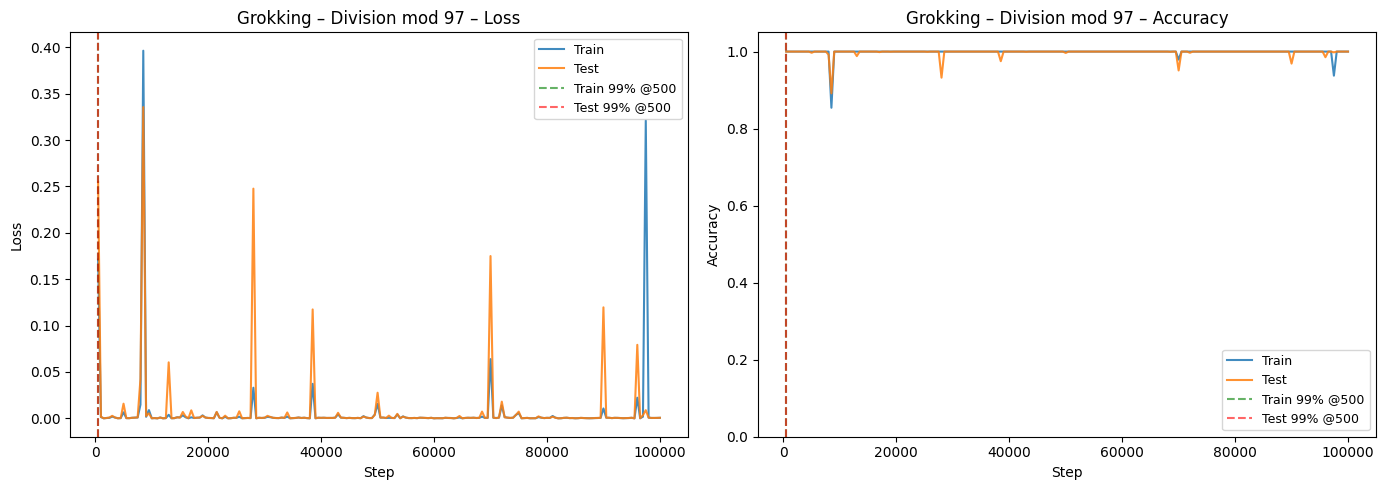


=== Inference demo ===
  5 / 3 mod 97 → predicted=34, expected=34  ✓
  12 / 7 mod 97 → predicted=71, expected=71  ✓
  50 / 25 mod 97 → predicted=2, expected=2  ✓
  0 / 1 mod 97 → predicted=0, expected=0  ✓


In [9]:
# @title 🌀 Cell 9: Part 2.3 – Grokking (Division mod 97)
P_GROK = 97
set_seed(42)
_, vs_grok = get_op_tokens(P_GROK)

# 50% train split is essential for grokking to occur
tr_div, _, te_div = generate_mod_data(P_GROK, '/', train_frac=0.5, val_frac=0.0, seed=42)
print(f"Division data: train={len(tr_div)}, test={len(te_div)}")

tr_dl_g = DataLoader(ModArithDataset(tr_div), batch_size=512, shuffle=True)
te_dl_g = DataLoader(ModArithDataset(te_div), batch_size=512)

cfg_grok  = GPTConfig(block_size=4, vocab_size=vs_grok,
                      n_layer=1, n_head=4, n_embd=128, dropout=0.0, bias=False)
model_grok = GPT(cfg_grok).to(DEVICE)

# High weight decay is the key ingredient for grokking
GROK_CFG = dict(lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98),
                max_steps=100_000, eval_interval=500, loss_type='last')

print("Training for grokking (this takes ~10-15 min on T4)...")
grok_m = train_model(model_grok, tr_dl_g, te_dl_g, GROK_CFG)

torch.save({'model_state_dict': model_grok.state_dict(),
            'config': cfg_grok, 'p': P_GROK, 'op': '/'}, 'grokking_div_p97.pt')
print("Checkpoint saved: grokking_div_p97.pt")

# ── Detect grokking ───────────────────────────────────────────────────────────
steps_g  = np.array(grok_m['step'])
tr_acc_g = np.array(grok_m['train_acc'])
te_acc_g = np.array(grok_m['test_acc'])
tr_99 = next((int(s) for s, a in zip(steps_g, tr_acc_g) if a > 0.99), None)
te_99 = next((int(s) for s, a in zip(steps_g, te_acc_g) if a > 0.99), None)
print(f"\nTrain acc >99% at step : {tr_99}")
print(f"Test  acc >99% at step : {te_99}")
if tr_99 and te_99:
    print(f"Grokking delay         : {te_99 - tr_99} steps")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in [(ax1,'loss','Loss'), (ax2,'acc','Accuracy')]:
    ax.plot(steps_g, grok_m[f'train_{key}'], label='Train', alpha=0.85)
    ax.plot(steps_g, grok_m[f'test_{key}'],  label='Test',  alpha=0.85)
    if tr_99: ax.axvline(tr_99, color='green', ls='--', alpha=0.6, label=f'Train 99% @{tr_99}')
    if te_99: ax.axvline(te_99, color='red',   ls='--', alpha=0.6, label=f'Test 99% @{te_99}')
    ax.set_title(f"Grokking – Division mod {P_GROK} – {title}")
    ax.set_xlabel("Step"); ax.set_ylabel(title); ax.legend(fontsize=9)
    if key == 'acc': ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig("grokking_div_p97.png", dpi=100); plt.show()

# ── Inference demo ────────────────────────────────────────────────────────────
print("\n=== Inference demo ===")
for a, b in [(5,3),(12,7),(50,25),(0,1)]:
    expected  = mod_div(a, b, P_GROK)
    predicted = predict_mod_arith(model_grok, a, b, '/', P_GROK)
    mark = "✓" if predicted == expected else "✗"
    print(f"  {a} / {b} mod {P_GROK} → predicted={predicted}, expected={expected}  {mark}")


>>> weight_decay = 0.0
GPT | params: 0.21M
  step   5000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0000 te_acc=1.000
  step  10000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0000 te_acc=1.000
  step  15000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0179 te_acc=0.998
  step  20000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0164 te_acc=0.999
  step  25000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0000 te_acc=1.000
  step  30000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0000 te_acc=1.000
  step  35000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0658 te_acc=0.996
  step  40000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0010 te_acc=1.000
  step  45000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0009 te_acc=1.000
  step  50000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0008 te_acc=1.000
  step  55000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0008 te_acc=1.000
  step  60000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0008 te_acc=1.000
  step  65000 | tr_loss=0.0000 tr_acc=1.000 | te_loss=0.0007 te_acc=

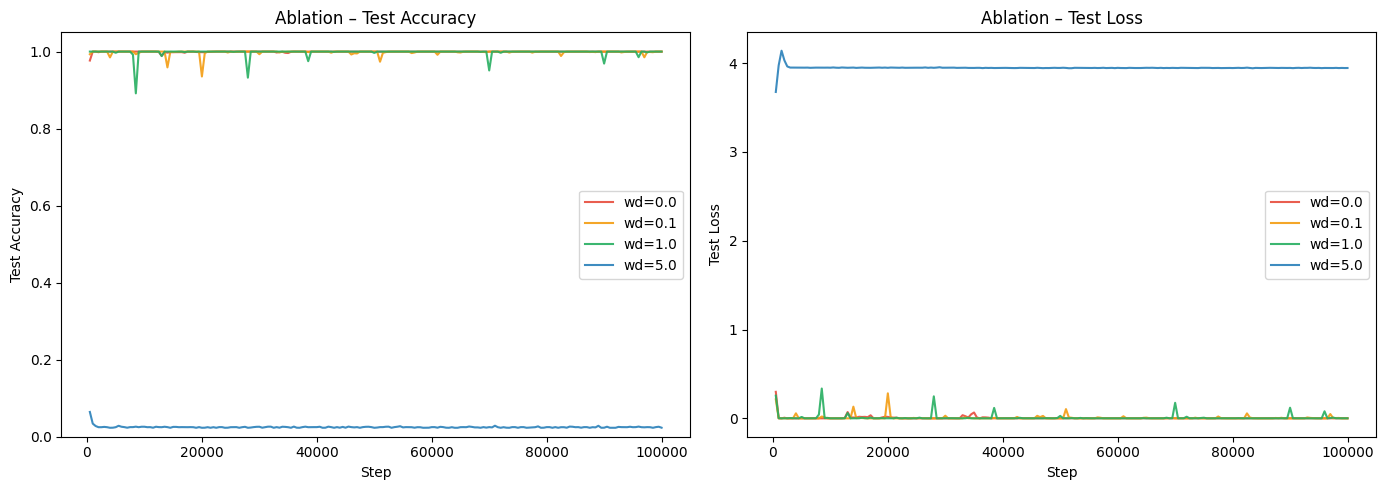


Weight Decay      Grokking Step   Final Test Acc
--------------------------------------------------
0.0                        1000            1.000
0.1                         500            1.000
1.0                         500            1.000
5.0                        None            0.023

✅ All experiments complete! Checkpoints + plots saved.


In [10]:
# @title 🔬 Cell 10: Part 2.4 – Ablation: Weight Decay vs Grokking Speed
# Motivation: weight decay acts as regularization that forces the model to
# find simpler, more generalisable solutions rather than pure memorisation.
# Literature (Nanda et al., 2023) confirms wd is among the strongest levers
# controlling how fast (or whether) grokking occurs.

WD_VALUES = [0.0, 0.1, 1.0, 5.0]
ablation_results = {}

for wd in WD_VALUES:
    print(f"\n>>> weight_decay = {wd}")
    set_seed(42)
    m_ab = GPT(GPTConfig(block_size=4, vocab_size=vs_grok,
                         n_layer=1, n_head=4, n_embd=128,
                         dropout=0.0, bias=False)).to(DEVICE)
    cfg_ab = dict(lr=1e-3, weight_decay=wd, betas=(0.9, 0.98),
                  max_steps=100_000, eval_interval=500, loss_type='last')
    ablation_results[wd] = train_model(m_ab, tr_dl_g, te_dl_g, cfg_ab)

print("\nAblation complete.")

# ── Plots ─────────────────────────────────────────────────────────────────────
colors = ['#e74c3c','#f39c12','#27ae60','#2980b9']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for (wd, met), c in zip(ablation_results.items(), colors):
    s = np.array(met['step'])
    ax1.plot(s, met['test_acc'],  color=c, label=f'wd={wd}', alpha=0.9)
    ax2.plot(s, met['test_loss'], color=c, label=f'wd={wd}', alpha=0.9)
ax1.set_title("Ablation – Test Accuracy"); ax1.set_xlabel("Step")
ax1.set_ylabel("Test Accuracy"); ax1.set_ylim(0, 1.05); ax1.legend()
ax2.set_title("Ablation – Test Loss"); ax2.set_xlabel("Step")
ax2.set_ylabel("Test Loss"); ax2.legend()
plt.tight_layout(); plt.savefig("ablation_weight_decay.png", dpi=100); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Weight Decay':<15} {'Grokking Step':>15} {'Final Test Acc':>16}")
print("-" * 50)
for wd, met in ablation_results.items():
    te_accs = np.array(met['test_acc'])
    gstep   = next((int(s) for s, a in zip(met['step'], te_accs) if a > 0.99), None)
    print(f"{wd:<15} {str(gstep):>15} {te_accs[-1]:>16.3f}")

print("\n✅ All experiments complete! Checkpoints + plots saved.")